<a href="https://colab.research.google.com/github/tharold4096/Tobias_INFO4670_Fall2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [2]:
# write your answer here
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

CSV_PATH = "/content/sample_data/bread_basket.csv"

bread = pd.read_csv(CSV_PATH)

print("Rows (item-level records): ", bread.shape[0])
print("Cols:", bread.shape[1])
print("Unique transactions:", bread['transaction'].nunique())
print("Unique items:", bread['item'].nunique())
bread.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Rows (item-level records):  20507
Cols: 6
Unique transactions: 9465
Unique items: 94


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [3]:

# write your answer here
print("Shape:", bread.shape)
print("Dtypes:")
print(bread.dtypes)
print("Nulls per column:")
print(bread.isna().sum())
bread.info()


Shape: (20507, 6)
Dtypes:
transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object
Nulls per column:
transaction        0
item               0
date_time          0
time               0
period_day         0
weekday_weekend    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [4]:
# write your answer here

bread.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

COntains 'NONE': False
Unique items total: 94
item
Coffee           4528
Bread            3097
Tea              1350
Cake              983
Pastry            815
Sandwich          680
Medialuna         585
Hot chocolate     552
Cookies           515
Brownie           379
Name: count, dtype: int64


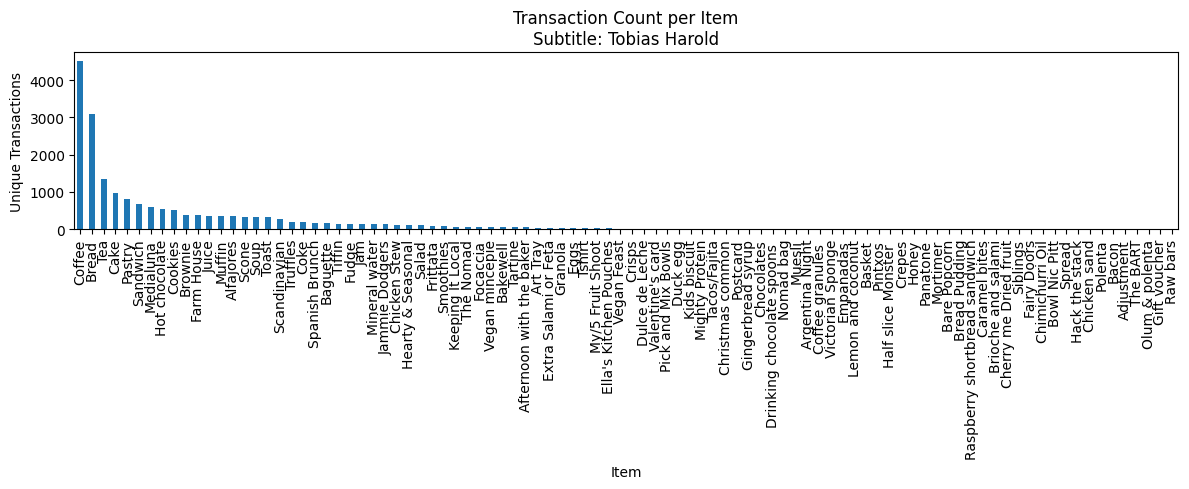

In [5]:
# c) Bar plot of transaction counts per item
subtitle = "Tobias Harold"  # <-- EDIT THIS

bread_unique = bread.drop_duplicates(subset=['transaction', 'item'])

print("COntains 'NONE':", 'NONE' in bread_unique['item'].unique())
item_counts =  (bread_unique['item'].value_counts().sort_values(ascending=False))

print("Unique items total:", len(item_counts))
print(item_counts.head(10))

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [6]:
# write your answer here
targets = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']

n_transactions = bread['transaction'].nunique()

for t in targets:
  count = item_counts.get(t, 0)
  pct = 100 * count /n_transactions
  print(f"{t:15s} {count:5d} transactions ({pct:.2f}% of all baskets)")


Coffee           4528 transactions (47.84% of all baskets)
Tea              1350 transactions (14.26% of all baskets)
Alfajores         344 transactions (3.63% of all baskets)
Juice             365 transactions (3.86% of all baskets)
Chicken Stew      123 transactions (1.30% of all baskets)


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [7]:
# write your answer here
basket = (bread.groupby('transaction')['item'].apply(list).reset_index().sort_values('transaction')['item'].tolist())
print("Basket built:", len(basket))

te_b = TransactionEncoder()
oht_b = pd.DataFrame(te_b.fit(basket).transform(basket), columns=te_b.columns_).astype(bool)
print("One-hot shape (transactions x items):", oht_b.shape)

minsup = 0.02
freq_b = fpgrowth(oht_b, min_support=minsup, use_colnames=True)
freq_b = freq_b.sort_values('support', ascending=False).reset_index(drop=True)


print(f"\nFrequent itemsets at min_support = {minsup}: {len(freq_b)}")
print("Breakdown by itemset size:")
print(freq_b['itemsets'].apply(len).value_counts().sort_index())

freq_b

Basket built: 9465
One-hot shape (transactions x items): (9465, 94)

Frequent itemsets at min_support = 0.02: 33
Breakdown by itemset size:
itemsets
1    19
2    14
Name: count, dtype: int64


,support,itemsets
0,0.478394,(Coffee)
1,0.327205,(Bread)
2,0.142631,(Tea)
3,0.103856,(Cake)
4,0.090016,"(Coffee, Bread)"
5,0.086107,(Pastry)
6,0.071844,(Sandwich)
7,0.061807,(Medialuna)
8,0.058320,(Hot chocolate)
9,0.054728,"(Coffee, Cake)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [12]:
# write your answer here

print("conf | n_rules")
for c in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60]:
    r = association_rules(freq_b, metric='confidence', min_threshold=c)
    print(f"{c:.2f} | {len(r)}")
minconf = 0.30

rules_b = association_rules(freq_b, metric='confidence', min_threshold=minconf)

rules_b['antecedents_str'] = rules_b['antecedents'].apply(lambda s: ', '.join(sorted(s)))
rules_b['consequents_str'] = rules_b['consequents'].apply(lambda s: ', '.join(sorted(s)))

report = (rules_b[['antecedents_str','consequents_str',
                   'support','confidence','lift']]
          .rename(columns={'antecedents_str':'Antecedent',
                           'consequents_str':'Consequent',
                           'support':'Support',
                           'confidence':'Confidence',
                           'lift':'Lift'})
          .sort_values(['Lift','Confidence'], ascending=False)
          .reset_index(drop=True)
          .round(4))

print(f"min_support = {minsup} | min_confidence = {minconf} | rules = {len(report)}")
report

conf | n_rules
0.15 | 16
0.20 | 13
0.25 | 11
0.30 | 10
0.35 | 8
0.40 | 8
0.50 | 8
0.60 | 1
min_support = 0.02 | min_confidence = 0.3 | rules = 10


,Antecedent,Consequent,Support,Confidence,Lift
0,Toast,Coffee,0.0237,0.7044,1.4724
1,Medialuna,Coffee,0.0352,0.5692,1.1899
2,Pastry,Coffee,0.0475,0.5521,1.1542
3,Juice,Coffee,0.0206,0.5342,1.1167
4,Sandwich,Coffee,0.0382,0.5324,1.1128
5,Cake,Coffee,0.0547,0.5270,1.1015
6,Cookies,Coffee,0.0282,0.5184,1.0837
7,Hot chocolate,Coffee,0.0296,0.5072,1.0603
8,Pastry,Bread,0.0292,0.3387,1.0350
9,Tea,Coffee,0.0499,0.3496,0.7308


In [10]:
#Need to check what the rule {Coffee, Cake} ⇒ {Bread} actually says about it

A = oht_b['Coffee'] & oht_b['Cake']
B = oht_b['Bread']

sup_A    = A.mean()
sup_B    = B.mean()
sup_AB   = (A & B).mean()
conf     = sup_AB / sup_A
lift     = conf / sup_B

print(f"support({{Coffee, Cake}}) = {sup_A:.4f}")
print(f"support({{Bread}}) = {sup_B:.4f}")
print(f"support({{Coffee, Cake, Bread}}) = {sup_AB:.4f}  ({(A & B).sum()} baskets)")
print(f"confidence = {conf:.4f}")
print(f"lift  = {lift:.4f}")
print(f"\nmin_support floor = {minsup} -> itemset {'clears' if sup_AB >= minsup else 'FALLS BELOW'} it")

support({Coffee, Cake}) = 0.0547
support({Bread}) = 0.3272
support({Coffee, Cake, Bread}) = 0.0100  (95 baskets)
confidence = 0.1834
lift  = 0.5605

min_support floor = 0.02 -> itemset FALLS BELOW it


**5 Rule Subgraph**

Rules among {'Coffee', 'Bread', 'Tea', 'Cake'}: 2


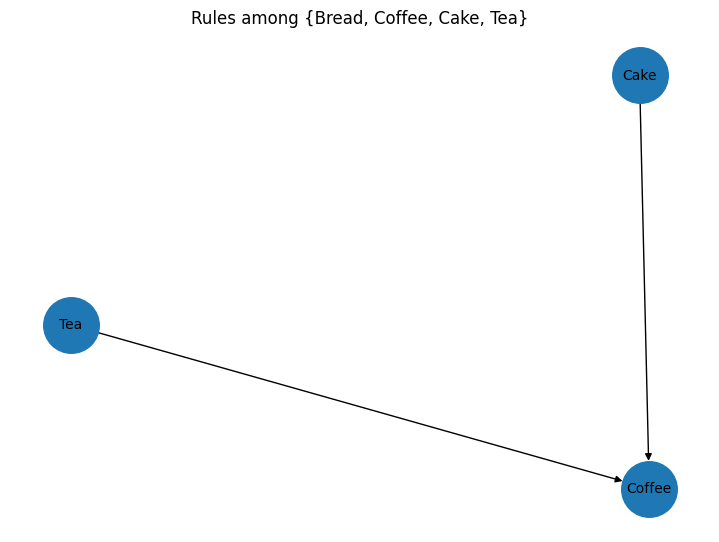

In [13]:
import networkx as nx

focus = {'Bread','Coffee','Cake','Tea'}
sub = rules_b[
    rules_b['antecedents'].apply(lambda s: s.issubset(focus)) &
    rules_b['consequents'].apply(lambda s: s.issubset(focus))
].copy()
print(f"Rules among {focus}: {len(sub)}")

G = nx.DiGraph()
for _, r in sub.iterrows():
    a = ','.join(sorted(list(r['antecedents'])))
    c = ','.join(sorted(list(r['consequents'])))
    G.add_edge(a, c, weight=float(r['confidence']), lift=float(r['lift']))

plt.figure(figsize=(7,5))
pos = nx.spring_layout(G, seed=0)
nx.draw(G, pos, with_labels=True, node_size=1600, font_size=10, arrows=True)
plt.title("Rules among {Bread, Coffee, Cake, Tea}")
plt.show()

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* The rule was not included in part 3 because the min_support of .02 only produced the item sets of 1 to 1. The mapping of the two to one was below the floor used in that portion. Once I grabbed it, we can see the support was at .0100, meaning that there were hardly any of the whole data of baskets contained all three. The confidence sat around .1834, which is less that the Bread normal rate of .327, showing alongside the lift of (.5605) that in this scenario, buying both coffee and cake actually lowers the chance of buying bread. A practical interpretation of this is that both cake and bread already have a < 1 lift on their own, meaning that both bread and cake are competing for the same slot- which would explain why both bread and cake are almost never bought with coffee

>